In [1]:
%load_ext autoreload
%autoreload 2  

In [2]:
import numpy as np, os, copy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from time import time
from itertools import permutations
import sys; sys.path.insert(0, '../')
from read_data import load_ts
import statistics
#import arbitrage as ar
from cointegracion import zscore_moving_win,inversion
import weights
import utils
import sys; sys.path.insert(0, '../')


In [3]:
class cnf:
    pathdat='./dat/' # directorio de los datos
    tipo='asset' # 'asset', 'return', 'log_return', 'log'
    Ntraining = 1000 # length of the training period
    beta_win=61   #21
    zscore_win=31 #11
    sigma_co=2.5 # thresold to buy optimizado en 1.5
    sigma_ve=0.1 # thresold to sell
    nmax=-1 #-1 #  10 # number of companies to generate the pairs (-1 all, 10 for testing)
    nsel=300 # 100 # 10 # number of best pairs to select
    linver_betaweight=0
    industry=['oil']
    fname=f'tmp/all_pair_' # fig filename
    shorten=0

In [4]:
# load data
day,date,price,company,volume = load_ts(sectors=cnf.industry, pathdat=cnf.pathdat)

In [5]:
metrics = statistics.all_pairs_stats(price[:,:cnf.Ntraining],company,'asset')
idx_selected_pairs = np.argsort(metrics.pvalue)[:cnf.nsel]

In [6]:

indices_permutations = list(permutations(range(price.shape[0]), 2))
idx_selected_assets = [indices_permutations[i] for i in idx_selected_pairs]

assets_l = [  [price[i,cnf.Ntraining:],
                  price[j,cnf.Ntraining:]]
                  for i,j in idx_selected_assets ]
print(company.shape)

company_l = [  [company[i],company[j]] for i,j in idx_selected_assets ]

# se realiza el procedimiento para cada uno de los pares
res_l=[]
for i, (x, y) in enumerate(assets_l):
    res_d = inversion(x,y,cnf)
    res_d['company']=company_l[i]        
    res_l.append( res_d )
        
res = utils.Results(res_l) # paso a objetos

(39,)


In [7]:
# --- IMPRIMIR LOS 10 PARES SELECCIONADOS Y SU P-VALOR ---

print("--- LOS 10 PARES SELECCIONADOS ---")
print(f"{'Ranking':<10} | {'Par de Empresas':<25} | {'p-value':<10}")
print("-" * 55)

for i, idx in enumerate(idx_selected_pairs):
    # Obtenemos el p-valor original de la matriz de métricas usando el índice
    pval = metrics.pvalue[idx]
    
    # Obtenemos los nombres de las empresas (company_l es una lista de listas)
    comp_A, comp_B = company_l[i]
    par_nombre = f"{comp_A} - {comp_B}"
    
    # Imprimimos la fila formateada
    print(f"Top {i+1:<6} | {par_nombre:<25} | {pval:.6f}")

--- LOS 10 PARES SELECCIONADOS ---
Ranking    | Par de Empresas           | p-value   
-------------------------------------------------------
Top 1      | EQT - SM                  | 0.000025
Top 2      | SM - EQT                  | 0.000062
Top 3      | CVX - EOG                 | 0.000112
Top 4      | ASC - SFL                 | 0.000177
Top 5      | DHT - ASC                 | 0.000196
Top 6      | EOG - CVX                 | 0.000265
Top 7      | RRC - EQT                 | 0.000482
Top 8      | EQT - RRC                 | 0.000606
Top 9      | MTR - KOS                 | 0.000622
Top 10     | SFL - ASC                 | 0.000689
Top 11     | NOG - OXY                 | 0.000695
Top 12     | SM - SFL                  | 0.000713
Top 13     | NOG - SFL                 | 0.000732
Top 14     | OKE - EOG                 | 0.000808
Top 15     | ASC - DHT                 | 0.001078
Top 16     | EQT - AR                  | 0.001180
Top 17     | EQT - SFL                 | 0.001184
Top 18 

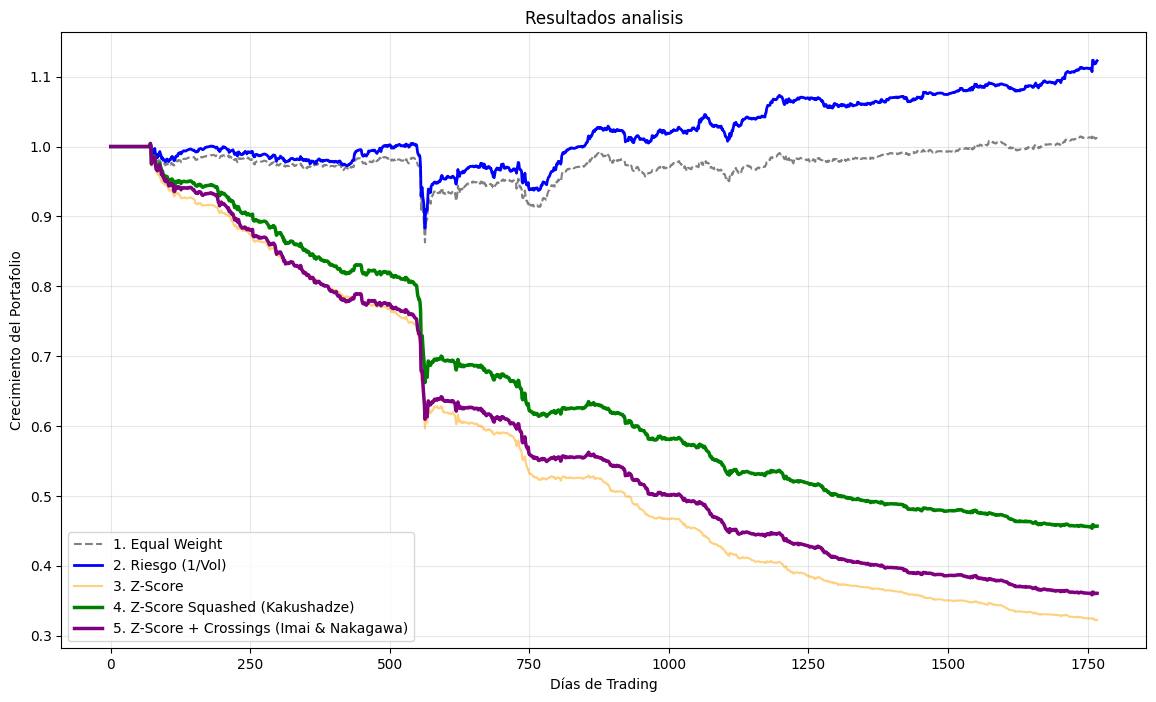

--- RENDIMIENTOS FINALES ---
1. Equal Weight(Base):         1.0115
2. Riesgo (1/Vol)(Kakushadze):       1.1228
3. Z-Score (Isichenko):         0.3221
4. Z-Score Squashed (Kakushadze):     0.4568
5. Z-Score + Crossings(Imai & Nakagawa):  0.3607


In [8]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

def analisis(res_l, period=50):
    plt.close('all')
    
    n_pairs = len(res_l)
    n_days = len(res_l[0]['zscore'])
    
    returns = np.zeros((n_pairs, n_days))
    positions = np.zeros((n_pairs, n_days))
    z_matrix = np.zeros((n_pairs, n_days))
    crossings_rate = np.zeros(n_pairs)
    
    # Riesgo base (Volatilidad del Spread de Kakushadze)
    spread_vols = np.array([np.nanstd(res_d['spread']) for res_d in res_l])
    
    for i, res_d in enumerate(res_l):
        z_array = np.nan_to_num(res_d['zscore'], nan=0.0)
        z_matrix[i, :] = z_array
        
        # --- NUEVO: Cálculo de Crossing Statistics (Imai & Nakagawa) ---
        # Contamos cuántas veces el spread cruzó el cero
        spread_array = np.nan_to_num(res_d['spread'], nan=0.0)
        zero_crossings = np.where(np.diff(np.sign(spread_array)))[0]
        # Tasa de cruces (Cruces totales / Días totales)
        crossings_rate[i] = len(zero_crossings) / n_days
        
        pos = np.zeros(n_days)
        pos[res_d['compras'] > 0] = 1
        pos[res_d['ccompras'] > 0] = -1
        positions[i, :] = pd.Series(pos).replace(0, np.nan).ffill().fillna(0).values
        
        cap = np.array(res_d.get('capital', np.ones(n_days)))
        ret = np.diff(cap) / (cap[:-1] + 1e-8)
        returns[i, -len(ret):] = np.nan_to_num(ret)


    # =============================================================
    # 1. EQUAL WEIGHT (Base Histórica)
    # =============================================================
    w_eq = np.abs(positions)
    sum_eq = w_eq.sum(axis=0); sum_eq[sum_eq == 0] = 1
    w_eq = w_eq / sum_eq

    # =============================================================
    # 2. RIESGO 1/Vol (Ganadora de Kakushadze)
    # =============================================================
    w_risk = np.abs(positions) / (spread_vols[:, None] + 1e-8)
    sum_risk = w_risk.sum(axis=0); sum_risk[sum_risk == 0] = 1
    w_risk = w_risk / sum_risk

    # =============================================================
    # 3. Z-SCORE PURO (El "Acelerador de Pérdidas")
    # =============================================================
    w_int = np.abs(positions * z_matrix)
    sum_int = w_int.sum(axis=0); sum_int[sum_int == 0] = 1
    w_int = w_int / sum_int

    # =============================================================
    # 4. Z-SCORE "SQUASHEADO" (Kakushadze Tanh)
    # =============================================================
    # Usamos tanh(|Z| / 2.0) para limitar el peso de los outliers extremos
    # y lo normalizamos por la volatilidad para mantener el control de riesgo.
    z_squashed = np.tanh(np.abs(z_matrix) / 2.0)
    w_z_squash = (np.abs(positions) * z_squashed) / (spread_vols[:, None] + 1e-8)
    sum_z_squash = w_z_squash.sum(axis=0); sum_z_squash[sum_z_squash == 0] = 1
    w_z_squash = w_z_squash / sum_z_squash

    # =============================================================
    # 5. Z-SCORE + CROSSING STATISTICS (Imai & Nakagawa)
    # =============================================================
    # Ponderamos el Z-Score por la frecuencia histórica de cruces por cero.
    w_z_cross = (np.abs(positions * z_matrix) * crossings_rate[:, None]) / (spread_vols[:, None] + 1e-8)
    sum_z_cross = w_z_cross.sum(axis=0); sum_z_cross[sum_z_cross == 0] = 1
    w_z_cross = w_z_cross / sum_z_cross

    # --- Calcular Curvas de Capital ---
    port_eq = np.cumprod(1 + np.sum(w_eq * returns, axis=0))
    port_risk = np.cumprod(1 + np.sum(w_risk * returns, axis=0))
    port_int = np.cumprod(1 + np.sum(w_int * returns, axis=0))
    port_z_squash = np.cumprod(1 + np.sum(w_z_squash * returns, axis=0))
    port_z_cross = np.cumprod(1 + np.sum(w_z_cross * returns, axis=0))

    # --- Graficar ---
    plt.figure(figsize=(14, 8))
    plt.plot(port_eq, label='1. Equal Weight', color='grey', linestyle='--')
    plt.plot(port_risk, label='2. Riesgo (1/Vol)', color='blue', linewidth=2)
    plt.plot(port_int, label='3. Z-Score', color='orange', alpha=0.5)
    plt.plot(port_z_squash, label='4. Z-Score Squashed (Kakushadze)', color='green', linewidth=2.5)
    plt.plot(port_z_cross, label='5. Z-Score + Crossings (Imai & Nakagawa)', color='purple', linewidth=2.5)
    
    plt.title('Resultados analisis')
    plt.ylabel('Crecimiento del Portafolio')
    plt.xlabel('Días de Trading')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Tabla de Resultados ---
    print(f"--- RENDIMIENTOS FINALES ---")
    print(f"1. Equal Weight(Base):         {port_eq[-1]:.4f}")
    print(f"2. Riesgo (1/Vol)(Kakushadze):       {port_risk[-1]:.4f}")
    print(f"3. Z-Score (Isichenko):         {port_int[-1]:.4f}")
    print(f"4. Z-Score Squashed (Kakushadze):     {port_z_squash[-1]:.4f}")
    print(f"5. Z-Score + Crossings(Imai & Nakagawa):  {port_z_cross[-1]:.4f}")


# Llama a la funcion para graficar y mostrar resultados:
analisis(res_l, period=1000)

In [9]:
import ipywidgets as widgets
from IPython.display import display
import time # Importamos time para la marca de tiempo

# 1. Generar opciones
options_multi = []
for i, comp in enumerate(company_l):
    pval = metrics.pvalue[idx_selected_pairs[i]]
    label = f"{i+1:02d}. {comp[0]} - {comp[1]}  (p-val: {pval:.6f})"
    options_multi.append((label, i))

# 2. Crear Widgets
pair_selector = widgets.SelectMultiple(
    options=options_multi,
    value=(0,),
    description='Pares:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='70%', height='250px')
)

btn_multi = widgets.Button(
    description='Analizar Selección',
    button_style='info',
    layout=widgets.Layout(width='200px')
)
out_multi = widgets.Output()

# 3. Lógica adaptada para VS Code
def on_btn_multi_clicked(b):
    b.disabled = True 
    
    # En VS Code, es más seguro limpiar el output llamando al método del objeto directamente
    out_multi.clear_output(wait=True) 
    
    with out_multi:
        selected = pair_selector.value
        
        if not selected:
            print('Selecciona al menos un par (Ctrl/Cmd + Click).')
            b.disabled = False
            return
            
        # Agregamos la hora exacta para depurar si es un bug visual o de ejecución
        hora_actual = time.strftime("%H:%M:%S")
        print(f'[{hora_actual}] Analizando {len(selected)} pares...')
        
        try:
            res_l_filtered = [res_l[i] for i in selected]
            analisis(res_l_filtered)
        except Exception as e:
            print(f"Ocurrió un error en el análisis: {e}")
        finally:
            b.disabled = False

# 4. Asignar el evento
btn_multi.on_click(on_btn_multi_clicked)

# 5. Mostrar
print('=== FILTRO INTERACTIVO DE PARES (Ordenados por P-Valor) ===')
print('Usa Ctrl (o Cmd en Mac) + Click para seleccionar múltiples pares.')
display(widgets.VBox([pair_selector, btn_multi, out_multi]))

=== FILTRO INTERACTIVO DE PARES (Ordenados por P-Valor) ===
Usa Ctrl (o Cmd en Mac) + Click para seleccionar múltiples pares.


In [10]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# 1. Generar opciones
options_single = []
for i, comp in enumerate(company_l):
    pval = metrics.pvalue[idx_selected_pairs[i]]
    label = f"{i+1:02d}. {comp[0]} - {comp[1]}  (p-val: {pval:.6f})"
    options_single.append((label, i))

# 2. Crear Widgets (SIEMPRE DESDE CERO para limpiar VS Code)
dropdown = widgets.Dropdown(
    options=options_single,
    value=options_single[0][1], # Seleccionamos el primer índice por defecto
    description='Seleccionar Par:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='70%')
)

out_single = widgets.Output()

# 3. Función de dibujo corregida y optimizada
def plot_pair(change):
    # Forzar el borrado inmediato y completo del Output en VS Code
    out_single.clear_output(wait=False)
    
    with out_single:
        idx = change['new'] if isinstance(change, dict) and 'new' in change else dropdown.value
        
        # Asegurar que Matplotlib NO acumule figuras anteriores
        plt.close('all')
        
        try:
            res_d = res_l[idx]
            comp_A, comp_B = company_l[idx]
            pval = metrics.pvalue[idx_selected_pairs[idx]]

            zscore   = np.nan_to_num(res_d['zscore'], nan=0.0)
            compras  = res_d['compras']
            ccompras = res_d['ccompras']

            # Precios normalizados a base 100
            pA = res_d['asset_x'];  nA = (pA / pA[0]) * 100
            pB = res_d['asset_y'];  nB = (pB / pB[0]) * 100

            # Capital del par
            cap = np.array(res_d.get('capital', np.ones(len(zscore))))
            if len(cap) < len(zscore):
                cap = np.pad(cap, (len(zscore) - len(cap), 0), constant_values=100.0)

            # Crear nueva figura limpia
            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12),
                                                 sharex=True,
                                                 gridspec_kw={'height_ratios': [1.5, 2, 1.5]})
            # --- Precios ---
            ax1.plot(nA, label=f'{comp_A}', color='purple')
            ax1.plot(nB, label=f'{comp_B}', color='brown')
            ax1.set_title(f'Precios Normalizados (Base 100): {comp_A} vs {comp_B}  |  p-val: {pval:.6f}')
            ax1.set_ylabel('Precio (Base 100)');  ax1.legend();  ax1.grid(alpha=0.3)

            # --- Z-Score y posiciones ---
            t = range(len(zscore))
            y_min = min(-4, zscore.min() - 0.5)
            y_max = max( 4, zscore.max() + 0.5)
            ax2.plot(t, zscore, color='black', linewidth=1, label='Z-Score')
            # Las líneas de entrada/salida usan sigma_co y sigma_ve de 'cnf' (asumimos disponible)
            ax2.axhline( cnf.sigma_co, color='red',   linestyle='--', alpha=0.6)
            ax2.axhline(-cnf.sigma_co, color='red',   linestyle='--', alpha=0.6)
            ax2.axhline( cnf.sigma_ve, color='green', linestyle='--', alpha=0.6)
            ax2.axhline(-cnf.sigma_ve, color='green', linestyle='--', alpha=0.6)
            ax2.fill_between(t, y_min, y_max, where=compras, color='blue', alpha=0.2)
            # CORRECCIÓN DE LA FALLA: line_width -> linewidth
            ax2.fill_between(t, y_min, y_max, linewidth=0, where=ccompras, color='orange', alpha=0.2)
            ax2.set_ylim(y_min, y_max)
            ax2.set_title('Z-Score y Posiciones Activas')
            ax2.set_ylabel('Z-Score');  ax2.legend(fontsize='small', loc='upper right');  ax2.grid(alpha=0.3)

            # --- Capital ---
            ax3.plot(t, cap, color='steelblue', label='Capital')
            ax3.fill_between(t, 100, cap, where=(cap >= 100), color='green', alpha=0.2)
            ax3.fill_between(t, 100, cap, where=(cap <  100), color='red',   alpha=0.2)
            ax3.axhline(100, color='black', linewidth=0.7)
            ax3.set_title('Capital del Par ($100 iniciales)')
            ax3.set_xlabel('Días');  ax3.set_ylabel('Capital')
            ax3.legend(loc='upper left');  ax3.grid(alpha=0.3)

            plt.tight_layout()
            # En VS Code, a veces es necesario un display() explícito de la figura
            # pero plt.show() suele funcionar si plt.close() se llamó antes.
            plt.show()
            
        except Exception as e:
            print(f"Error al graficar el par {idx}: {e}")

# 4. Registrar el evento
dropdown.observe(plot_pair, names='value')

# 5. Mostrar Interfaz
print('=== INSPECCIÓN INDIVIDUAL DE PAR ===')
display(dropdown, out_single)

# 6. Forzar el primer gráfico
plot_pair({'new': dropdown.value})

=== INSPECCIÓN INDIVIDUAL DE PAR ===


Dropdown(description='Seleccionar Par:', layout=Layout(width='70%'), options=(('01. EQT - SM  (p-val: 0.000025…

Output()

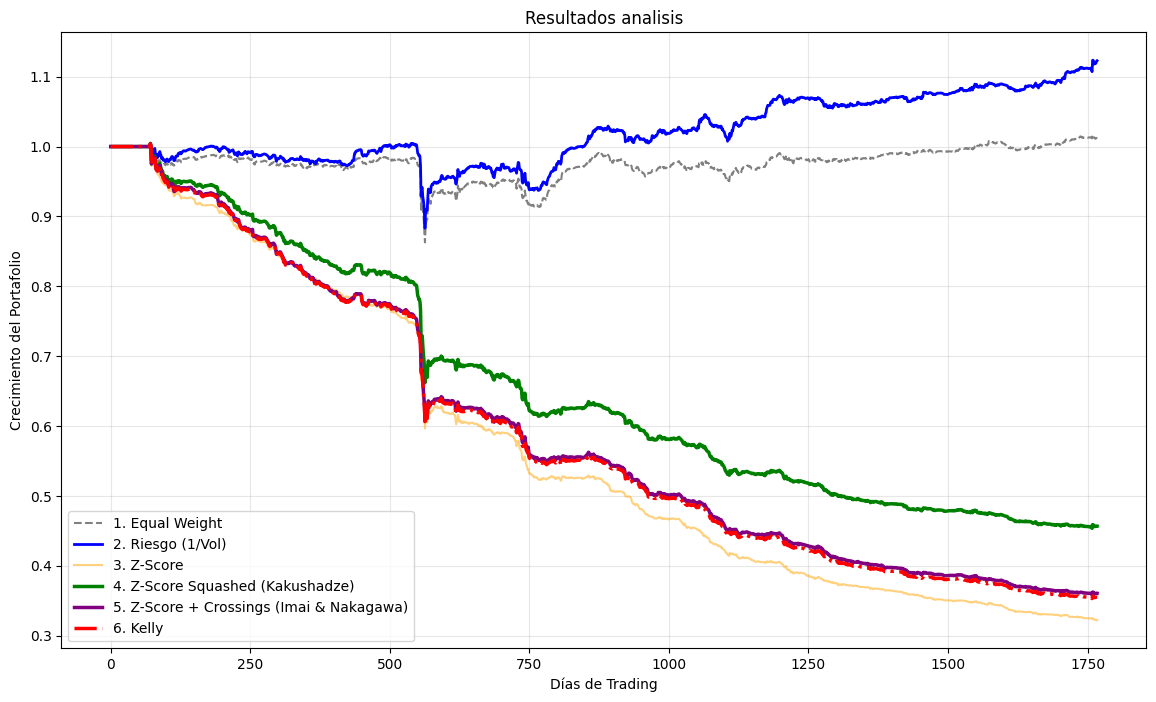

--- RENDIMIENTOS FINALES ---
1. Equal Weight(Base):         1.0115
2. Riesgo (1/Vol)(Kakushadze):       1.1228
3. Z-Score (Isichenko):         0.3221
4. Z-Score Squashed (Kakushadze):     0.4568
5. Z-Score + Crossings(Imai & Nakagawa):  0.3607
6. Kelly: 0.3549


In [11]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

def analisis(res_l):
    plt.close('all')
    
    n_pairs = len(res_l)
    n_days = len(res_l[0]['zscore'])
    
    returns = np.zeros((n_pairs, n_days))
    positions = np.zeros((n_pairs, n_days))
    z_matrix = np.zeros((n_pairs, n_days))
    crossings_rate = np.zeros(n_pairs)
    
    # Riesgo base (Volatilidad del Spread de Kakushadze)
    spread_vols = np.array([np.nanstd(res_d['spread']) for res_d in res_l])
    
    for i, res_d in enumerate(res_l):
        z_array = np.nan_to_num(res_d['zscore'], nan=0.0)
        z_matrix[i, :] = z_array
        
        # --- NUEVO: Cálculo de Crossing Statistics (Imai & Nakagawa) ---
        # Contamos cuántas veces el spread cruzó el cero
        spread_array = np.nan_to_num(res_d['spread'], nan=0.0)
        zero_crossings = np.where(np.diff(np.sign(spread_array)))[0]
        # Tasa de cruces (Cruces totales / Días totales)
        crossings_rate[i] = len(zero_crossings) / n_days
        
        pos = np.zeros(n_days)
        pos[res_d['compras'] > 0] = 1
        pos[res_d['ccompras'] > 0] = -1
        positions[i, :] = pd.Series(pos).replace(0, np.nan).ffill().fillna(0).values
        
        cap = np.array(res_d.get('capital', np.ones(n_days)))
        ret = np.diff(cap) / (cap[:-1] + 1e-8)
        returns[i, -len(ret):] = np.nan_to_num(ret)


    w_eq       = weights.equal_weight(positions)
    w_risk     = weights.risk_parity_weight(positions, spread_vols)
    w_int      = weights.zscore_pure_weight(positions, z_matrix)
    w_z_squash = weights.zscore_squashed_weight(positions, z_matrix, spread_vols)
    w_z_cross  = weights.crossings_weight(positions, z_matrix, spread_vols, crossings_rate)
    w_kelly    = weights.kelly_dynamic_weight(positions, z_matrix, spread_vols)

    # --- Calcular Curvas de Capital ---
    port_eq = np.cumprod(1 + np.sum(w_eq * returns, axis=0))
    port_risk = np.cumprod(1 + np.sum(w_risk * returns, axis=0))
    port_int = np.cumprod(1 + np.sum(w_int * returns, axis=0))
    port_z_squash = np.cumprod(1 + np.sum(w_z_squash * returns, axis=0))
    port_z_cross = np.cumprod(1 + np.sum(w_z_cross * returns, axis=0))
    port_kelly    = np.cumprod(1 + np.sum(w_kelly * returns, axis=0))

    # --- Graficar ---
    plt.figure(figsize=(14, 8))
    plt.plot(port_eq, label='1. Equal Weight', color='grey', linestyle='--')
    plt.plot(port_risk, label='2. Riesgo (1/Vol)', color='blue', linewidth=2)
    plt.plot(port_int, label='3. Z-Score', color='orange', alpha=0.5)
    plt.plot(port_z_squash, label='4. Z-Score Squashed (Kakushadze)', color='green', linewidth=2.5)
    plt.plot(port_z_cross, label='5. Z-Score + Crossings (Imai & Nakagawa)', color='purple', linewidth=2.5)
    plt.plot(port_kelly, label='6. Kelly', color='red', linewidth=2.5, linestyle='-.')

    
    plt.title('Resultados analisis')
    plt.ylabel('Crecimiento del Portafolio')
    plt.xlabel('Días de Trading')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Tabla de Resultados ---
    print(f"--- RENDIMIENTOS FINALES ---")
    print(f"1. Equal Weight(Base):         {port_eq[-1]:.4f}")
    print(f"2. Riesgo (1/Vol)(Kakushadze):       {port_risk[-1]:.4f}")
    print(f"3. Z-Score (Isichenko):         {port_int[-1]:.4f}")
    print(f"4. Z-Score Squashed (Kakushadze):     {port_z_squash[-1]:.4f}")
    print(f"5. Z-Score + Crossings(Imai & Nakagawa):  {port_z_cross[-1]:.4f}")
    print(f"6. Kelly: {port_kelly [-1]:.4f}")


# Llama a la funcion para graficar y mostrar resultados:
analisis(res_l)

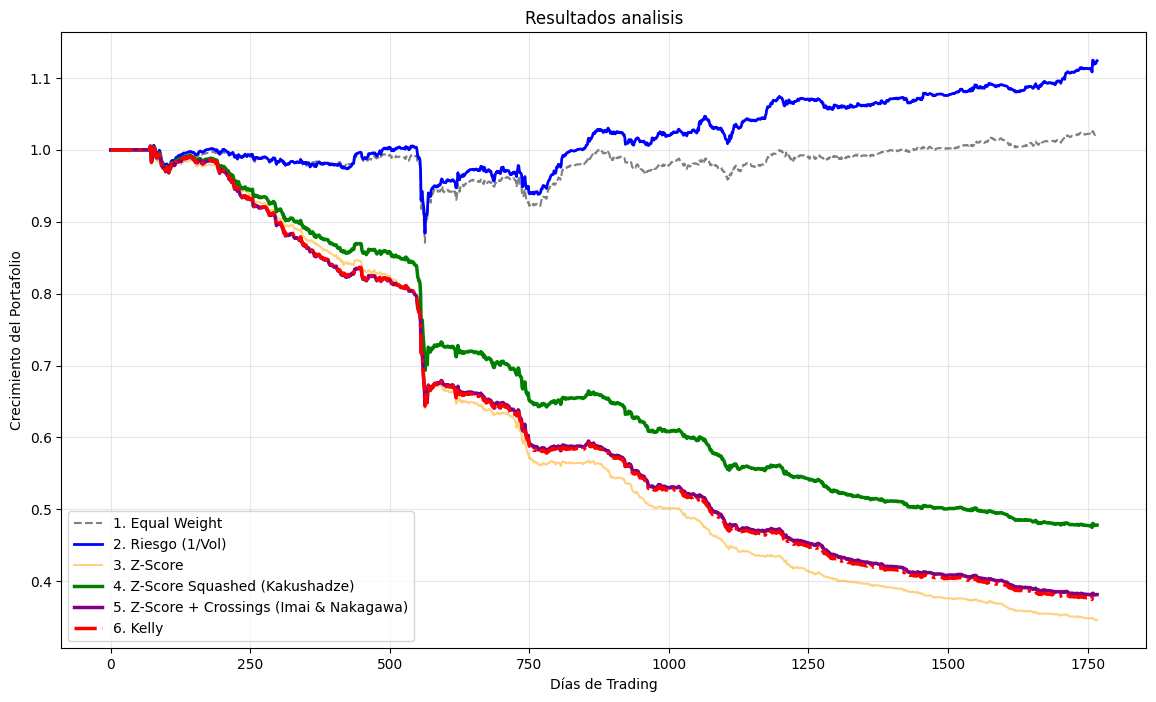

--- RENDIMIENTOS FINALES ---
1. Equal Weight(Base):         1.0207
2. Riesgo (1/Vol)(Kakushadze):       1.1239
3. Z-Score (Isichenko):         0.3458
4. Z-Score Squashed (Kakushadze):     0.4782
5. Z-Score + Crossings(Imai & Nakagawa):  0.3816
6. Kelly: 0.3767


In [12]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

def analisis(res_l,half_lives):
    plt.close('all')
    
    n_pairs = len(res_l)
    n_days = len(res_l[0]['zscore'])
    
    returns = np.zeros((n_pairs, n_days))
    positions = np.zeros((n_pairs, n_days))
    z_matrix = np.zeros((n_pairs, n_days))
    crossings_rate = np.zeros(n_pairs)
    
    # Riesgo base (Volatilidad del Spread de Kakushadze)
    spread_vols = np.array([np.nanstd(res_d['spread']) for res_d in res_l])
    
    for i, res_d in enumerate(res_l):
        z_array = np.nan_to_num(res_d['zscore'], nan=0.0)
        z_matrix[i, :] = z_array
        
        # --- NUEVO: Cálculo de Crossing Statistics (Imai & Nakagawa) ---
        # Contamos cuántas veces el spread cruzó el cero
        spread_array = np.nan_to_num(res_d['spread'], nan=0.0)
        zero_crossings = np.where(np.diff(np.sign(spread_array)))[0]
        # Tasa de cruces (Cruces totales / Días totales)
        crossings_rate[i] = len(zero_crossings) / n_days
        
        pos = np.zeros(n_days)
        pos[res_d['compras'] > 0] = 1
        pos[res_d['ccompras'] > 0] = -1
        positions[i, :] = pd.Series(pos).replace(0, np.nan).ffill().fillna(0).values
        
        cap = np.array(res_d.get('capital', np.ones(n_days)))
        ret = np.diff(cap) / (cap[:-1] + 1e-8)
        returns[i, -len(ret):] = np.nan_to_num(ret)


    w_eq       = weights.equal_weight(positions)
    w_eq       = weights.apply_hold_period(w_eq, positions, half_lives)
    w_risk     = weights.risk_parity_weight(positions, spread_vols)
    w_risk     = weights.apply_hold_period(w_risk, positions, half_lives)
    w_int      = weights.zscore_pure_weight(positions, z_matrix)
    w_int      = weights.apply_hold_period(w_int, positions, half_lives)
    w_z_squash = weights.zscore_squashed_weight(positions, z_matrix, spread_vols)
    w_z_squash = weights.apply_hold_period(w_z_squash, positions, half_lives)
    w_z_cross  = weights.crossings_weight(positions, z_matrix, spread_vols, crossings_rate)
    w_z_cross  = weights.apply_hold_period(w_z_cross,positions,half_lives)
    w_kelly    = weights.kelly_dynamic_weight(positions, z_matrix, spread_vols)
    w_kelly    = weights.apply_hold_period(w_kelly,positions, half_lives)

    # --- Calcular Curvas de Capital ---
    port_eq = np.cumprod(1 + np.sum(w_eq * returns, axis=0))
    port_risk = np.cumprod(1 + np.sum(w_risk * returns, axis=0))
    port_int = np.cumprod(1 + np.sum(w_int * returns, axis=0))
    port_z_squash = np.cumprod(1 + np.sum(w_z_squash * returns, axis=0))
    port_z_cross = np.cumprod(1 + np.sum(w_z_cross * returns, axis=0))
    port_kelly    = np.cumprod(1 + np.sum(w_kelly * returns, axis=0))

    # --- Graficar ---
    plt.figure(figsize=(14, 8))
    plt.plot(port_eq, label='1. Equal Weight', color='grey', linestyle='--')
    plt.plot(port_risk, label='2. Riesgo (1/Vol)', color='blue', linewidth=2)
    plt.plot(port_int, label='3. Z-Score', color='orange', alpha=0.5)
    plt.plot(port_z_squash, label='4. Z-Score Squashed (Kakushadze)', color='green', linewidth=2.5)
    plt.plot(port_z_cross, label='5. Z-Score + Crossings (Imai & Nakagawa)', color='purple', linewidth=2.5)
    plt.plot(port_kelly, label='6. Kelly', color='red', linewidth=2.5, linestyle='-.')

    
    plt.title('Resultados analisis')
    plt.ylabel('Crecimiento del Portafolio')
    plt.xlabel('Días de Trading')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Tabla de Resultados ---
    print(f"--- RENDIMIENTOS FINALES ---")
    print(f"1. Equal Weight(Base):         {port_eq[-1]:.4f}")
    print(f"2. Riesgo (1/Vol)(Kakushadze):       {port_risk[-1]:.4f}")
    print(f"3. Z-Score (Isichenko):         {port_int[-1]:.4f}")
    print(f"4. Z-Score Squashed (Kakushadze):     {port_z_squash[-1]:.4f}")
    print(f"5. Z-Score + Crossings(Imai & Nakagawa):  {port_z_cross[-1]:.4f}")
    print(f"6. Kelly: {port_kelly [-1]:.4f}")


# Llama a la funcion para graficar y mostrar resultados:
hl_list = [metrics.half_life[idx] for idx in idx_selected_pairs]
analisis(res_l,hl_list)